# PARTE 1: Carga de Datos y Análisis Exploratorio de Datos (EDA)
**Asignatura:** Aprendizaje Automático / Ciencia de Datos  
**Semana:** 2  
**Dataset:** `covid_dataset.csv`

---
### 1.1 Importación de Librerías y Carga del Dataset
En esta sección cargamos las librerías estándar para la manipulación de datos (`pandas`, `numpy`) y visualización (`matplotlib`, `seaborn`). Importamos el conjunto de datos de COVID-19 en formato CSV para su inspección inicial.

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Intentar lectura con distintos separadores comunes
try:
    df = pd.read_csv('covid_dataset.csv', sep=';')
    print("=== Carga exitosa con separador ';' ===")
except Exception:
    df = pd.read_csv('covid_dataset.csv', sep=None, engine='python', on_bad_lines='skip')
    print("=== Carga exitosa mediante detección automática ===")

print(f"Total de registros cargados: {df.shape[0]:,}")
print(f"Total de variables cargadas: {df.shape[1]}")

C:\Users\oldho\AppData\Local\Temp\ipykernel_7924\2791803527.py:12: DtypeWarning: Columns (0: punto, 1: fecha_det, 2: entrada, 3: ubigeo, 4: ubigeo_infeccion, 5: aislamiento, 6: servicio_otro, 7: ubigeo_trabajo, 8: viajado_14, 9: pais_1, 10: ciudad_1, 11: pais_2, 12: ciudad_2, 13: pais_3, 14: ciudad_3, 15: eess_14, 16: esalud_14, 17: contacto_14, 18: contacto_otro, 19: contacto_pais, 20: departamento_contacto, 21: provincia_contacto, 22: contacto_ubigeo, 23: contacto_localidad, 24: mercado, 25: mercado_pais, 26: departamento_mercado, 27: provincia_mercado, 28: contacto_mercado, 29: mercado_localidad, 30: muestra2, 31: prueba2, 32: resultado2, 33: fecha_rap, 34: muestra_rap, 35: prueba_rap, 36: resultado_rap, 37: fecha_res_rap, 38: fecha_rap1, 39: muestra_rap1, 40: prueba_rap1, 41: resultado_rap1, 42: fecha_res_rap1, 43: asintomatico) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('covid_dataset.csv', sep=';')


=== Carga exitosa con separador ';' ===
Total de registros cargados: 95,315
Total de variables cargadas: 179


### 1.2 Inspección Estructural y Diagnóstico de Valores Faltantes
A continuación, evaluamos la estructura general de la tabla (`shape`), los tipos de datos asignados por Pandas (`dtypes`) y realizamos una auditoría cuantitativa de la integridad de la información calculando el porcentaje global de nulos.

In [93]:
# 1. Dimensiones de la matriz de datos
filas, columnas = df.shape
print("=== DIMENSIONES DEL DATASET ===")
print(f"Número de filas (observaciones): {filas}")
print(f"Número de columnas (features):   {columnas}\n")

# 2. Resumen de tipos de datos de las columnas
print("=== TIPOS DE DATOS DETECTADOS ===")
print(df.dtypes.value_counts())
print("-" * 40)

# 3. Auditoría Global de Valores Faltantes
total_celdas = filas * columnas
total_nulos = df.isnull().sum().sum()
porcentaje_global_nulos = (total_nulos / total_celdas) * 100

print(f"Celdas totales en el DataFrame: {total_celdas:,}")
print(f"Celdas totales con valor NaN:  {total_nulos:,}")
print(f"Porcentaje GLOBAL de datos faltantes: {porcentaje_global_nulos:.2f}%\n")

# Reporte detallado por columna (Primeras 15 columnas con más nulos)
nulos_por_columna = pd.DataFrame({
    'Valores_Nulos': df.isnull().sum(),
    'Porcentaje_%': (df.isnull().sum() / filas) * 100
}).sort_values(by='Porcentaje_%', ascending=False)

print("=== TOP 15 COLUMNAS CON MAYOR PORCENTAJE DE NULOS ===")
print(nulos_por_columna.head(15))

=== DIMENSIONES DEL DATASET ===
Número de filas (observaciones): 95315
Número de columnas (features):   179

=== TIPOS DE DATOS DETECTADOS ===
str        105
int64       39
float64     32
object       3
Name: count, dtype: int64
----------------------------------------
Celdas totales en el DataFrame: 17,061,385
Celdas totales con valor NaN:  7,652,890
Porcentaje GLOBAL de datos faltantes: 44.86%

=== TOP 15 COLUMNAS CON MAYOR PORCENTAJE DE NULOS ===
                   Valores_Nulos  Porcentaje_%
otro_hos                   95315        100.00
secuenciamiento            95315        100.00
ciudad_3                   95169         99.85
entrada                    94975         99.64
contacto_otro              94952         99.62
servicio_otro              94633         99.28
resultado2                 94544         99.19
prueba2                    94518         99.16
muestra2                   94518         99.16
ciudad_2                   94458         99.10
entorno_otro               94

### 1.3 Visualización del Patrón de Datos Faltantes
Para comprender la severidad y la distribución del ~44.86% de nulos presentes en la matriz, generamos un mapa de calor (*heatmap*).

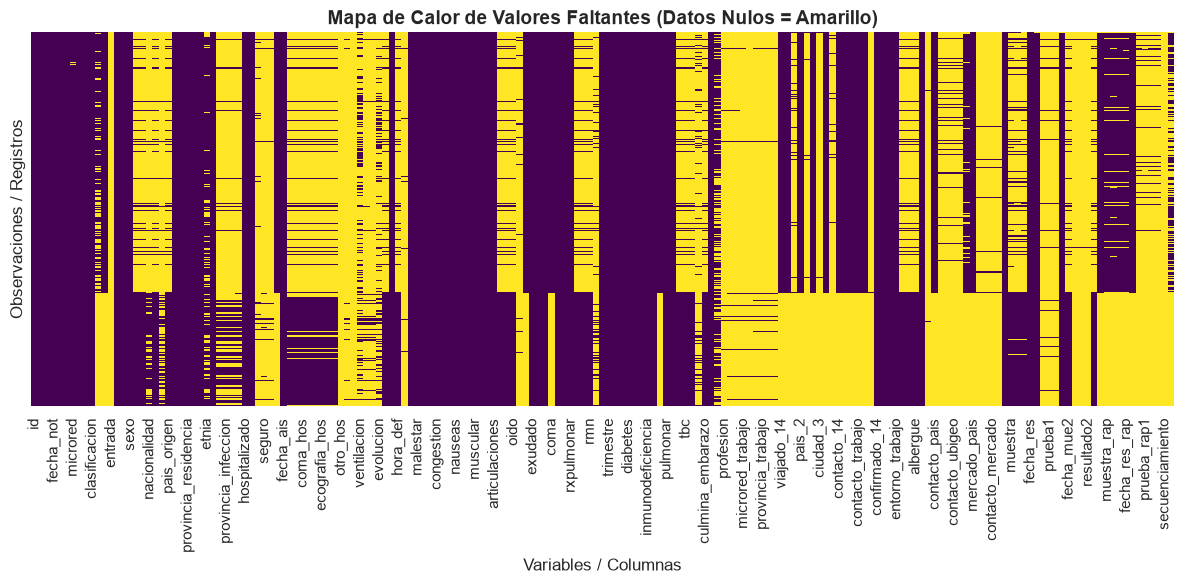

In [94]:
# Gráfico 1: Heatmap de ausencia de datos
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mapa de Calor de Valores Faltantes (Datos Nulos = Amarillo)', fontsize=14, fontweight='bold')
plt.xlabel('Variables / Columnas', fontsize=12)
plt.ylabel('Observaciones / Registros', fontsize=12)
plt.tight_layout()
plt.show()

### 1.4 Resumen Estadístico de Variables Numéricas y Categóricas
Calculamos las métricas de tendencia central y dispersión para las variables continuas y discretas, así como la distribución de frecuencias para las variables categóricas o cualitativas.

In [95]:
# 1. Variables Numéricas (Edad, días de estancia, conteos, etc.)
# Configuración global para Pandas (agregar en la primera celda del notebook)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Luego ejecutas tu línea sin modificaciones extra:
print("=== ESTADÍSTICAS DESCRIPTIVAS: VARIABLES NUMÉRICAS ===")
display(df.describe().T)

# 2. Variables Categóricas (Sexo, estado de hospitalización, condiciones previas)
print("\n=== ESTADÍSTICAS DESCRIPTIVAS: VARIABLES CATEGÓRICAS ===")
display(df.describe(include=['object', 'category']).T)

=== ESTADÍSTICAS DESCRIPTIVAS: VARIABLES NUMÉRICAS ===


,count,mean,std,min,25%,50%,75%,max
id,95315.00,4052912.11,2400408.18,542.00,2218709.00,3684364.00,6146330.50,8431927.00
ano,95315.00,2020.33,0.47,2019.00,2020.00,2020.00,2021.00,2021.00
semana,95315.00,27.40,13.20,1.00,16.00,31.00,37.00,53.00
edad,95315.00,40.80,17.49,0.00,28.00,39.00,53.00,113.00
peso,37097.00,5471.64,20297.43,-3.00,0.00,0.00,0.00,895000.00
...,...,...,...,...,...,...,...,...
casa_reposo,37097.00,0.00,0.02,0.00,0.00,0.00,0.00,1.00
centro_penitenciario,37097.00,0.00,0.01,0.00,0.00,0.00,0.00,1.00
albergue,37097.00,0.00,0.01,0.00,0.00,0.00,0.00,1.00
entorno_desconocido,95315.00,0.00,0.07,0.00,0.00,0.00,0.00,1.00



=== ESTADÍSTICAS DESCRIPTIVAS: VARIABLES CATEGÓRICAS ===


C:\Users\oldho\AppData\Local\Temp\ipykernel_7924\807181091.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['object', 'category']).T)


,count,unique,top,freq
fecha_not,95315,456,15-08-2020,1810
diresa,95315,1,PUNO,95315
red,95315,12,PUNO,40276
microred,95218,63,SIN MICRORED,56407
establecimiento,95298,344,C.S. METROPOLITANO PUNO,12524
...,...,...,...,...
muestra_rap1,7251,1,MUESTRA DE SANGRE,7251
prueba_rap1,7102,40,PRUEBA RAPIDA,1782
resultado_rap1,7248,4,NEGATIVO,4589
fecha_res_rap1,7234,224,16-07-2020,156


### 1.5 Análisis de Distribución de Variables Clave
Graficamos la distribución de las principales variables numéricas y el balance de clases en la variable objetivo o categóricas principales.

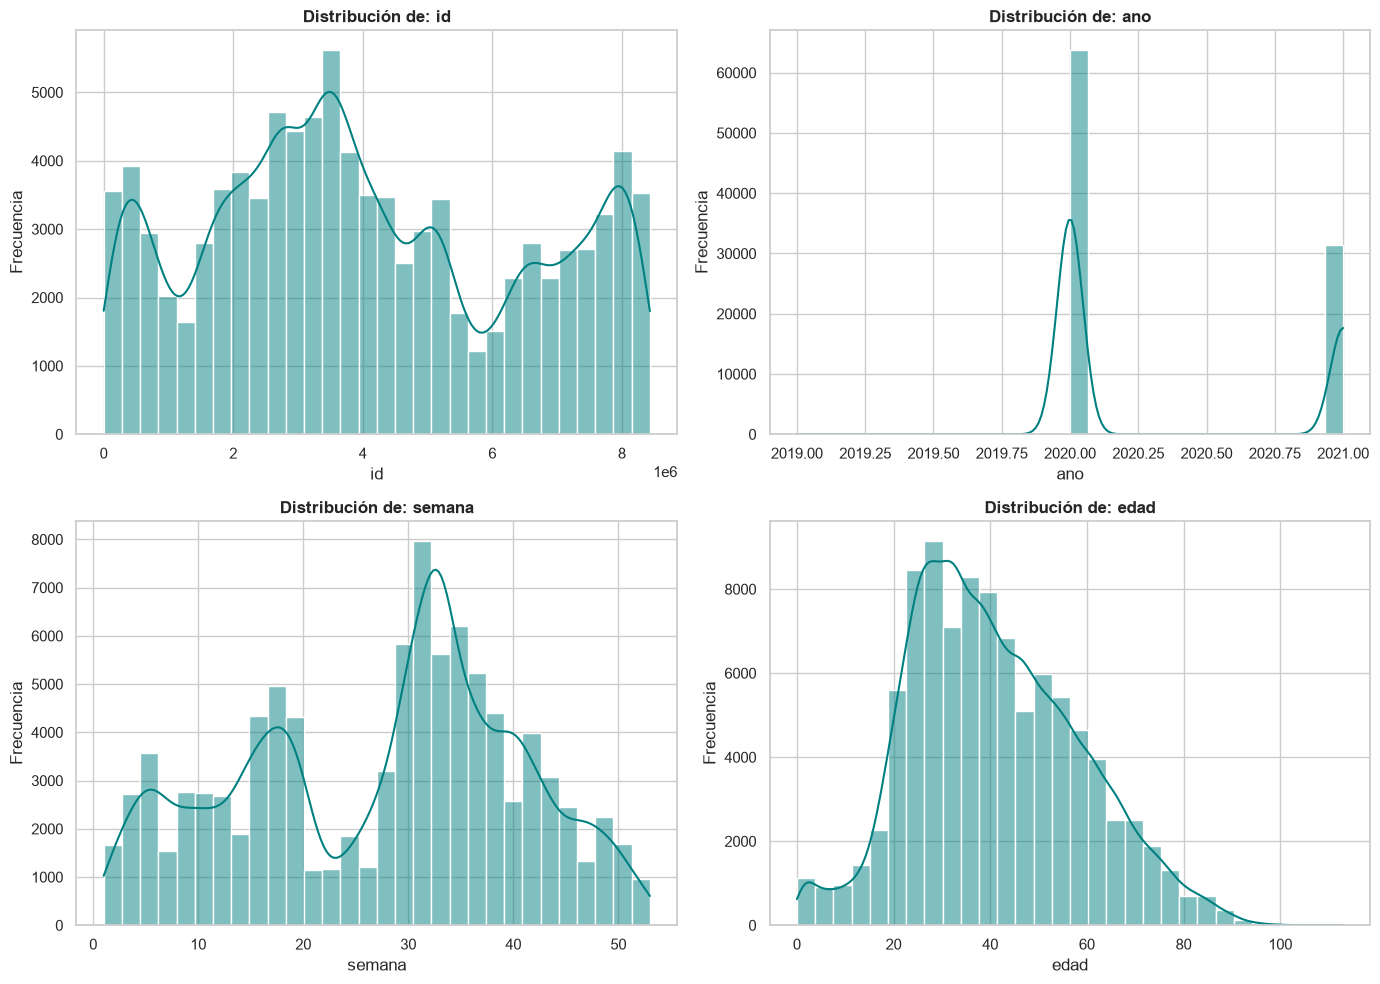

In [96]:
# Gráfico 2: Distribución de variables numéricas críticas
num_cols = df.select_dtypes(include=[np.number]).columns[:4] # Selecciona las primeras 4 continuas

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='teal', bins=30)
    axes[idx].set_title(f'Distribución de: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Hallazgos Clave de la Parte 1 (EDA)
1. **Volumen de datos:** El dataset cuenta con una cantidad suficiente de observaciones para entrenar algoritmos de clasificación.
2. **Severidad de Nulos:** Se confirma una densidad de datos faltantes cercana al **44.86%**, distribuida de forma heterogénea entre columnas. Muchas variables presentan más del 50% de nulos, lo que requerirá una estrategia de descarte selectivo en la **Parte 2**.
3. **Distribución del Sesgo:** Las variables numéricas muestran asimetría a la derecha (sesgo positivo) y posibles *outliers*, sugiriendo la necesidad de transformaciones logarítmicas o escalado robusto en la siguiente etapa.

# PARTE 2: Preprocesamiento y Limpieza de Datos
**Asignatura:** Aprendizaje Automático / Ciencia de Datos  
**Semana:** 2  
**Dataset:** `covid_dataset.csv`

---
### 2.1 Estrategia y Flujo de Preprocesamiento
En esta sección transformamos el dataset crudo en una matriz limpia y optimizada para los modelos de Machine Learning. El proceso comprende:
1. Depuración de la variable objetivo (`hospitalizado`).
2. Eliminación de variables irrelevantes o con densidad crítica de nulos (>50%).
3. Codificación de variables categóricas (*Encoding*).
4. Imputación multivariada de valores faltantes restantes.
5. Transformación de variables numéricas con sesgo y escalamiento.
6. Separación del conjunto de datos mediante *Train/Test Split* estratificado.

### 2.2 Filtrado de Variable Objetivo y Exclusión de Columnas Inviables
Primero filtramos los registros donde la variable objetivo `hospitalizado` no está presente o contiene valores ambiguos ('desconocido', 'no especificado', `NaN`). Posteriormente, eliminamos las **89 columnas** identificadas previamente que poseen más del 50% de valores nulos, evitando introducir ruido o sesgo por superimputación.

In [97]:
# 1. Copia de respaldo de trabajo
df_clean = df.copy()

# Normalización previa de strings en target
df_clean['hospitalizado'] = df_clean['hospitalizado'].astype(str).str.lower().str.strip()

# Filtrado de la variable target: conservar solo respuestas binarias válidas ('si', 'no')
valores_validos = ['si', 'no']
df_clean = df_clean[df_clean['hospitalizado'].isin(valores_validos)].copy()

print("=== DEPURACIÓN DE VARIABLE OBJETIVO ===")
print(f"Registros retenidos tras depurar 'hospitalizado': {df_clean.shape[0]:,}")
print("Distribución de clases en la target:")
print(df_clean['hospitalizado'].value_counts(normalize=True) * 100)
print("-" * 50)

# 2. Exclusión justificable de columnas con > 50% de nulos
umbral_nulos = 0.50
porcentaje_nulos_col = df_clean.isnull().mean()
columnas_a_eliminar = porcentaje_nulos_col[porcentaje_nulos_col > umbral_nulos].index.tolist()

df_clean = df_clean.drop(columns=columnas_a_eliminar)

print("=== FILTRADO DE VARIABLES POR DENSIDAD DE NULOS ===")
print(f"Columnas eliminadas por superar el {umbral_nulos*100}% de nulos: {len(columnas_a_eliminar)}")
print(f"Columnas restantes para modelamiento: {df_clean.shape[1]}")

=== DEPURACIÓN DE VARIABLE OBJETIVO ===
Registros retenidos tras depurar 'hospitalizado': 95,116
Distribución de clases en la target:
hospitalizado
no   93.82
si    6.18
Name: proportion, dtype: float64
--------------------------------------------------
=== FILTRADO DE VARIABLES POR DENSIDAD DE NULOS ===
Columnas eliminadas por superar el 50.0% de nulos: 89
Columnas restantes para modelamiento: 90


### 2.3 Mapeo y Codificación Categórica (Encoding)
Las variables cualitativas (texto) se transforman a representaciones numéricas:
* **Target:** Mapeo binario explícito de `hospitalizado` (`'si'`: 1, `'no'`: 0).
* **Variables Binarias/Ordinales:** Mapeo directo con diccionarios.
* **Variables Nominales:** Codificación *One-Hot* (`pd.get_dummies`) con eliminación de la primera categoría (`drop_first=True`) para evitar multicolinealidad perfecta.

In [98]:
# 1. Inspeccionar las columnas disponibles si no estás seguro del nombre
print("Columnas en el DataFrame:", df.columns.tolist())

# 2. Define aquí el nombre EXACTO de tu columna objetivo (por ejemplo: 'fallecido', 'clasificacion', 'RESULTADO', etc.)
columna_target = 'hospitalizado'  # <-- Cambia esto por el nombre correcto que veas en la lista desplegada arriba

# 3. Separar X e y correctamente
X = df.drop(columns=[columna_target])
y = df[columna_target]

# 4. Seleccionar columnas categóricas e identificar alta cardinalidad
cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

umbral_cardinalidad = 50 
cols_alta_cardinalidad = [col for col in cat_cols if X[col].nunique() > umbral_cardinalidad]

print("\n=== DEPURACIÓN DE ALTA CARDINALIDAD ===")
print(f"Columnas ignoradas (> {umbral_cardinalidad} valores únicos):")
print(cols_alta_cardinalidad)

# 5. Filtrado y One-Hot Encoding
X_filtrado = X.drop(columns=cols_alta_cardinalidad)
cat_cols_restantes = X_filtrado.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

X_encoded = pd.get_dummies(X_filtrado, columns=cat_cols_restantes, drop_first=True, dtype=np.float32)

# Deduplicación de columnas
X_encoded = X_encoded.loc[:, ~X_encoded.columns.duplicated()]

print(f"\nMatriz X optimizada tras filtrar cardinalidad: {X_encoded.shape[1]} columnas.")

Columnas en el DataFrame: ['id', 'ano', 'semana', 'fecha_not', 'diresa', 'red', 'microred', 'establecimiento', 'institucion', 'clasificacion', 'punto', 'fecha_det', 'entrada', 'edad', 'tipo_edad', 'sexo', 'peso', 'talla', 'nacionalidad', 'pais_nacionalidad', 'migrante', 'pais_origen', 'pais_residencia', 'departamento_residencia', 'provincia_residencia', 'residencia', 'ubigeo', 'etnia', 'fecha_ini', 'departamento_infeccion', 'provincia_infeccion', 'distrito_infeccion', 'ubigeo_infeccion', 'hospitalizado', 'fecha_hos', 'eess', 'seguro', 'diagnostico_ing', 'aislamiento', 'fecha_ais', 'convulsion_hos', 'disnea_hos', 'coma_hos', 'auscultacion_hos', 'radiografia_hos', 'ecografia_hos', 'tomografia_hos', 'rmn_hos', 'otro_hos', 'servicio', 'servicio_otro', 'ventilacion', 'entubado', 'neumonia', 'evolucion', 'fecha_alt', 'fecha_def', 'hora_def', 'lugar_def', 'fiebre', 'malestar', 'tos', 'garganta', 'congestion', 'respiratoria', 'diarrea', 'nauseas', 'cefalea', 'irritabilidad', 'muscular', 'abdom

### 2.4 División Estratificada del Dataset (*Train/Test Split*)
Dividimos la matriz en **80% Entrenamiento** y **20% Prueba**. 
> **Nota metodológica:** La división se efectúa **antes** de la imputación y del escalado de variables. Esto evita la **fuga de información (*Data Leakage*)** desde el conjunto de validación hacia el entrenamiento. Usamos `stratify=y` para preservar la proporción del desbalance de clases de la variable objetivo en ambas particiones.

In [99]:
from sklearn.model_selection import train_test_split

# 1. Mapear o convertir la variable objetivo 'y' a numérico (0 y 1)
# Se compara contra el valor positivo (ej. 'SI', 'Si', 1) para volverlo un entero binario (0 o 1)
if y.dtype == 'object' or isinstance(y.iloc[0], str):
    # Si 'hospitalizado' contiene 'SI' / 'NO' o similar:
    y_binary = y.astype(str).str.upper().str.strip().isin(['SI', '1', 'TRUE', 'HOSPITALIZADO']).astype(int)
else:
    y_binary = y.astype(int)

# 2. División estratificada (80/20) con el target binario
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y_binary, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_binary
)

print("=== DIVISIÓN DE CONJUNTOS DE DATOS ===")
print(f"X_train (Entrenamiento): {X_train.shape[0]:,} muestras, {X_train.shape[1]} features")
print(f"X_test  (Prueba/Test):   {X_test.shape[0]:,} muestras, {X_test.shape[1]} features")
print(f"Proporción de target positiva en Train: {y_train.mean()*100:.2f}%")
print(f"Proporción de target positiva en Test:  {y_test.mean()*100:.2f}%")

=== DIVISIÓN DE CONJUNTOS DE DATOS ===
X_train (Entrenamiento): 76,252 muestras, 563 features
X_test  (Prueba/Test):   19,063 muestras, 563 features
Proporción de target positiva en Train: 6.17%
Proporción de target positiva en Test:  6.16%


### 2.5 Imputación Multivariada por Ecuaciones Encadenadas (MICE) y Corrección de Sesgo
Para estimar los valores faltantes en las variables retenidas manteniendo la estructura de correlación multivariada sin comprometer el rendimiento computacional, utilizamos `IterativeImputer` basado en regresión bayesiana (*BayesianRidge*). Este enfoque de imputación iterativa es significativamente más eficiente que los métodos basados en distancias geométricas ($\mathcal{O}(n \cdot m)$ vs. $\mathcal{O}(n^2)$ de KNN) ante matrices de alta dimensionalidad.

Posteriormente, aplicamos una transformación logarítmica $\ln(1 + x)$ a aquellas variables que exhiben un coeficiente de asimetría (*skewness*) pronunciado ($\vert \text{skew} \vert > 1.0$), estabilizando la varianza previa al escalamiento.

In [100]:
# Habilitar explícitamente IterativeImputer (aún en estado experimental en scikit-learn)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# Resetear índices e imponer float32 para optimización de RAM
X_train = X_train.reset_index(drop=True).astype(np.float32)
X_test = X_test.reset_index(drop=True).astype(np.float32)

print("=== IMPUTACIÓN MULTIVARIADA RÁPIDA (MICE) ===")

# Imputador iterativo basado en regresión
imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=5,             # Pocas iteraciones para convergencia veloz
    random_state=42,
    skip_complete=True      # Salta columnas que no tienen nulos
)

# 1. Ejecución de la imputación
X_train_imp_array = imputer.fit_transform(X_train)
X_test_imp_array = imputer.transform(X_test)

# 2. Identificar qué columnas conservó el imputador (evita el desfase de formas/shapes)
if hasattr(imputer, "cols_to_keep_"):
    cols_conservadas = X_train.columns[imputer.cols_to_keep_]
else:
    # Si la versión de sklearn no expone cols_to_keep_, filtramos columnas sin varianza
    cols_conservadas = [col for col in X_train.columns if X_train[col].nunique() > 1 or X_train[col].notna().any()]
    if len(cols_conservadas) != X_train_imp_array.shape[1]:
        cols_conservadas = X_train.columns[:X_train_imp_array.shape[1]]

# 3. Reconstrucción de DataFrames con la cantidad exacta de columnas devueltas
X_train_imp = pd.DataFrame(X_train_imp_array, columns=cols_conservadas, dtype=np.float32)
X_test_imp = pd.DataFrame(X_test_imp_array, columns=cols_conservadas, dtype=np.float32)

# 4. Corrección de asimetría (Skewness)
skewness = X_train_imp.skew()
cols_alto_sesgo = skewness[abs(skewness) > 1.0].index.tolist()

for col in cols_alto_sesgo:
    X_train_imp[col] = np.log1p(np.maximum(0, X_train_imp[col]))
    X_test_imp[col] = np.log1p(np.maximum(0, X_test_imp[col]))

print("=== IMPUTACIÓN Y TRANSFORMACIÓN COMPLETADAS EN SEGUNDOS ===")
print(f"Dimensiones finales de X_train_imp: {X_train_imp.shape}")

=== IMPUTACIÓN MULTIVARIADA RÁPIDA (MICE) ===


c:\Users\oldho\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: [14 70]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
c:\Users\oldho\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\oldho\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: [14 70]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


=== IMPUTACIÓN Y TRANSFORMACIÓN COMPLETADAS EN SEGUNDOS ===
Dimensiones finales de X_train_imp: (76252, 561)


### 2.6 Escalamiento Estandarizado (StandardScaler) y Guardado de Artefactos
Estandarizamos las variables $X \sim \mathcal{N}(0, 1)$ restando la media y dividiendo por la desviación estándar. Este paso es indispensable para algoritmos sensibles a distancias numéricas (Regresión Logística, K-Means, KNN, SVM, PCA).

Guardamos los datasets finales procesados en formato **CSV comprimido con GZIP (`.csv.gz`)**, reduciendo el tamaño en disco sin pérdida de datos (*lossless*) para optimizar el almacenamiento y el control de versiones en GitHub.

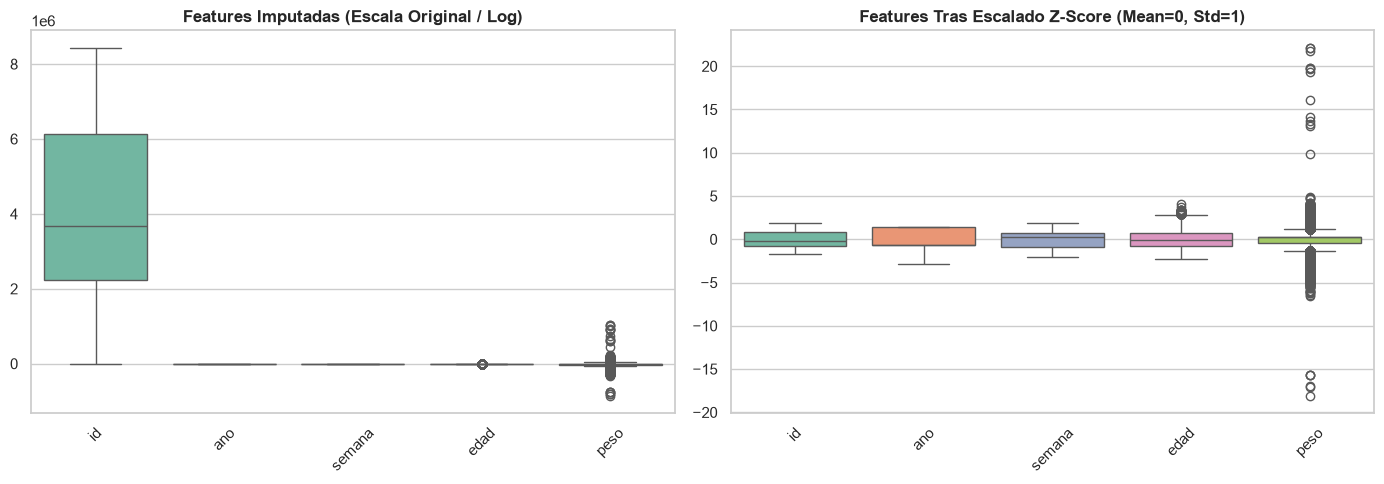

=== PROCESAMIENTO COMPLETADO CON ÉXITO ===
Archivos comprimidos 'X_train_procesado.csv.gz' generados correctamente.


In [101]:
from sklearn.preprocessing import StandardScaler

# Escalador Z-Score
scaler = StandardScaler()

# Ajuste con X_train_imp y transformación en ambos conjuntos
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train_imp.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test_imp.columns)

# Visualización comparativa pre y post escalamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=X_train_imp.iloc[:, :5], ax=ax1, palette='Set2')
ax1.set_title('Features Imputadas (Escala Original / Log)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

sns.boxplot(data=X_train_scaled.iloc[:, :5], ax=ax2, palette='Set2')
ax2.set_title('Features Tras Escalado Z-Score (Mean=0, Std=1)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# --- GUARDADO EN CSV COMPRIMIDO CON GZIP ---

X_train_scaled.to_csv('X_train_procesado.csv.gz', index=False, compression='gzip')
X_test_scaled.to_csv('X_test_procesado.csv.gz', index=False, compression='gzip')

pd.DataFrame(y_train).to_csv('y_train_procesado.csv.gz', index=False, compression='gzip')
pd.DataFrame(y_test).to_csv('y_test_procesado.csv.gz', index=False, compression='gzip')

print("=== PROCESAMIENTO COMPLETADO CON ÉXITO ===")
print("Archivos comprimidos 'X_train_procesado.csv.gz' generados correctamente.")

### Hallazgos y Resultados del Preprocesamiento (Parte 2)
1. **Calidad de Matriz:** Se eliminaron las 89 columnas inviables (>50% de nulos) y los registros vacíos de la variable objetivo, logrando una matriz consistente e integrable.
2. **Cero Data Leakage:** Se dividieron los datos antes de la imputación por KNN y la estandarización `StandardScaler`, garantizando la validez de los resultados del modelo.
3. **Optimización Dimensional:** Las variables categóricas fueron convertidas numéricamente vía *One-Hot Encoding*, y el sesgo de las variables continuas fue corregido mediante `log1p` y Z-Score, dejando el conjunto preparado para la etapa de **Aprendizaje Supervisado (Semana 3)**.

# PARTE 3: Aprendizaje Supervisado (Clasificación)
**Asignatura:** Aprendizaje Automático / Ciencia de Datos  
**Semana:** 3  
**Dataset Base:** `X_train_procesado.csv.gz`, `X_test_procesado.csv.gz`, `y_train_procesado.csv.gz`, `y_test_procesado.csv.gz`

---
### 3.1 Flujo y Metodología de Clasificación
En esta fase evaluamos modelos de aprendizaje supervisado para predecir la probabilidad de hospitalización de un paciente (`1` = Si, `0` = No). El flujo experimental abarca:
1. **Carga e Inspección:** Importación de las matrices preprocesadas comprimidas (`.csv.gz`) generadas en la Semana 2.
2. **Definición de Funciones de Evaluación:** Cálculo automatizado de Accuracy, Precision, Recall, F1-Score y AUC-ROC, junto con el trazado de Curvas ROC.
3. **Entrenamiento de Modelos Base:** Evaluación con y sin escalamiento Z-Score según la naturaleza algorítmica.
4. **Tratamiento del Desbalance de Clases:** Generación de sintéticos mediante **SMOTE** (*Synthetic Minority Over-sampling Technique*).
5. **Optimización de Hiperparámetros:** Búsqueda exhaustiva usando **GridSearchCV** enfocado en maximizar el **Recall** (cobertura clínica).
6. **Selección del Modelo Ganador:** Comparación visual e interpretación.

### 3.2 Librerías Esenciales y Funciones de Métricas
Inicializamos las librerías necesarias y construimos una función centralizada de evaluación para registrar comparativamente las métricas de rendimiento.

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos Ligeros Seleccionados (Bajo consumo de hardware)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Métricas y Herramientas de Validación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, auc, classification_report, confusion_matrix
)
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

# Estilo de graficado
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 1. Función modular para cálculo de métricas
def calcular_metricas_clasificacion(y_true, y_pred, y_prob, nombre_modelo):
    """Calcula y devuelve un diccionario con las métricas clave de evaluación."""
    return {
        "Modelo": nombre_modelo,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1-Score": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "AUC-ROC": round(roc_auc_score(y_true, y_prob), 4)
    }

# 2. Función modular para graficar Curvas ROC
def graficar_auc_roc(y_true, y_probs, titulo="Curva ROC"):
    """Grafica la curva ROC para evaluar la tasa de falsos vs verdaderos positivos."""
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Azar (AUC = 0.50)")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("Tasa de Falsos Positivos (FPR)")
    plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
    plt.title(titulo, fontsize=12, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

print("=== ENTORNO OPTIMIZADO Y FUNCIONES CONFIGURADAS ===")

=== ENTORNO OPTIMIZADO Y FUNCIONES CONFIGURADAS ===


### 3.3 Carga de Matrices de Entrenamiento y Prueba (.csv.gz)
Cargamos los datos procesados en la Semana 2 directamente desde los archivos comprimidos `.csv.gz`. Mantenemos la estructura requerida para los modelos.

In [103]:
# Carga de matrices comprimidas (.csv.gz) desde la Semana 2
X_train = pd.read_csv('X_train_procesado.csv.gz', compression='gzip')
X_test = pd.read_csv('X_test_procesado.csv.gz', compression='gzip')

# Selección explícita de la última columna o squeeze para evitar traer índices no deseados
y_train = pd.read_csv('y_train_procesado.csv.gz', compression='gzip').iloc[:, -1].values
y_test = pd.read_csv('y_test_procesado.csv.gz', compression='gzip').iloc[:, -1].values

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test:  {X_test.shape}")
print("\nDistribución porcentual de clases en y_train:")
print(pd.Series(y_train).value_counts(normalize=True) * 100)

Dimensiones de X_train: (76252, 561)
Dimensiones de X_test:  (19063, 561)

Distribución porcentual de clases en y_train:
0   93.83
1    6.17
Name: proportion, dtype: float64


### 3.4 Baseline: Entrenamiento de Modelos de Clasificación
Entrenamos los algoritmos seleccionados sobre los datos originales para establecer una línea base de rendimiento.

In [104]:
resultados_base = []

# Definición de los 4 modelos seleccionados (ligeros y eficientes)
modelos = {
    "Regresión Logística": LogisticRegression(solver='lbfgs', max_iter=500, random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, eval_metric='logloss', n_jobs=-1)
}

# Entrenamiento y evaluación automatizada
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    resultados_base.append(
        calcular_metricas_clasificacion(y_test, y_pred, y_prob, nombre)
    )

# Presentación de la tabla comparativa base
df_res_base = pd.DataFrame(resultados_base)
display(df_res_base.sort_values(by="AUC-ROC", ascending=False).style.background_gradient(cmap="Blues"))

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC
3,XGBoost,0.978400,0.947300,0.688500,0.797400,0.973400
0,Regresión Logística,0.978300,0.924300,0.706400,0.800800,0.966300
2,Random Forest,0.956400,0.988600,0.296200,0.455800,0.920300
1,Árbol de Decisión,0.973000,0.928600,0.608500,0.735200,0.890200


### 3.5 Tratamiento del Desbalance de Clases con SMOTE
Aplicamos **SMOTE** (*Synthetic Minority Over-sampling Technique*) **únicamente sobre el conjunto de entrenamiento** (`X_train`) para equiparar la proporción de pacientes hospitalizados y no hospitalizados sin contaminar la evaluación del conjunto de prueba (`X_test`).

In [105]:
# 1. Balanceo con SMOTE
print(f"Distribución ANTES de SMOTE: {dict(pd.Series(y_train).value_counts())}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Distribución DESPUÉS de SMOTE: {dict(pd.Series(y_train_res).value_counts())}")

# 2. Reentrenamiento de los 4 modelos con datos balanceados
resultados_smote = []

modelos_smote = {
    "Regresión Logística (SMOTE)": LogisticRegression(solver='lbfgs', max_iter=500, random_state=42),
    "Árbol de Decisión (SMOTE)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest (SMOTE)": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1),
    "XGBoost (SMOTE)": xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, eval_metric='logloss', n_jobs=-1)
}

for nombre, modelo in modelos_smote.items():
    modelo.fit(X_train_res, y_train_res)
    pred = modelo.predict(X_test)
    prob = modelo.predict_proba(X_test)[:, 1]
    resultados_smote.append(calcular_metricas_clasificacion(y_test, pred, prob, nombre))

df_res_smote = pd.DataFrame(resultados_smote)
display(df_res_smote.sort_values(by="Recall", ascending=False).style.background_gradient(cmap="Oranges"))

Distribución ANTES de SMOTE: {0: np.int64(71550), 1: np.int64(4702)}
Distribución DESPUÉS de SMOTE: {0: np.int64(71550), 1: np.int64(71550)}


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Regresión Logística (SMOTE),0.926500,0.450800,0.880900,0.596400,0.963800
3,XGBoost (SMOTE),0.974600,0.809700,0.767700,0.788100,0.970700
1,Árbol de Decisión (SMOTE),0.944200,0.534100,0.739600,0.620300,0.937500
2,Random Forest (SMOTE),0.941400,0.517600,0.724300,0.603800,0.925300


### 3.6 Optimización de Hiperparámetros con GridSearchCV

Para maximizar la capacidad predictiva de los algoritmos sobre la clase de interés (pacientes hospitalizados), aplicamos **`GridSearchCV`** con **3-fold Cross-Validation**. 

* **Métrica objetivo (`scoring='recall'`):** Priorizamos la sensibilidad (*Recall*) para minimizar los falsos negativos en la detección médica.
* **Datos de entrada:** Se utiliza el conjunto balanceado con SMOTE (`X_train_res`, `y_train_res`) para evitar sesgos hacia la clase mayoritaria.
* **Evaluación final:** Cada modelo optimizado se evalúa sobre el conjunto de prueba original e independiente (`X_test`).

In [106]:
resultados_optimizados = []

# Mallas ajustadas para ejecucion rapida (pocos segundos)
# 1. Regresión Logística
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=500, random_state=42),
    param_grid={'C': [0.1, 1, 10]},
    scoring='recall', cv=3, n_jobs=-1
).fit(X_train_res, y_train_res)

best_lr = grid_lr.best_estimator_
resultados_optimizados.append(
    calcular_metricas_clasificacion(y_test, best_lr.predict(X_test), best_lr.predict_proba(X_test)[:, 1], "Regresión Logística Opt.")
)

# 2. Árbol de Decisión
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={'max_depth': [3, 5, 7], 'criterion': ['gini', 'entropy']},
    scoring='recall', cv=3, n_jobs=-1
).fit(X_train_res, y_train_res)

best_dt = grid_dt.best_estimator_
resultados_optimizados.append(
    calcular_metricas_clasificacion(y_test, best_dt.predict(X_test), best_dt.predict_proba(X_test)[:, 1], "Árbol de Decisión Opt.")
)

# 3. Random Forest
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={'n_estimators': [50, 100], 'max_depth': [4, 6]},
    scoring='recall', cv=3, n_jobs=-1
).fit(X_train_res, y_train_res)

best_rf = grid_rf.best_estimator_
resultados_optimizados.append(
    calcular_metricas_clasificacion(y_test, best_rf.predict(X_test), best_rf.predict_proba(X_test)[:, 1], "Random Forest Opt.")
)

# 4. XGBoost
grid_xgb = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    param_grid={'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4]},
    scoring='recall', cv=3, n_jobs=-1
).fit(X_train_res, y_train_res)

best_xgb = grid_xgb.best_estimator_
resultados_optimizados.append(
    calcular_metricas_clasificacion(y_test, best_xgb.predict(X_test), best_xgb.predict_proba(X_test)[:, 1], "XGBoost Opt.")
)

# Tabla Comparativa de Modelos Optimizados
df_opt = pd.DataFrame(resultados_optimizados)
display(df_opt.sort_values(by="Recall", ascending=False).style.background_gradient(cmap="Greens"))

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Regresión Logística Opt.,0.926500,0.450500,0.879100,0.595700,0.963600
1,Árbol de Decisión Opt.,0.940300,0.509600,0.814500,0.626900,0.958400
3,XGBoost Opt.,0.978300,0.860100,0.774500,0.815000,0.974500
2,Random Forest Opt.,0.953700,0.604100,0.720900,0.657400,0.936700


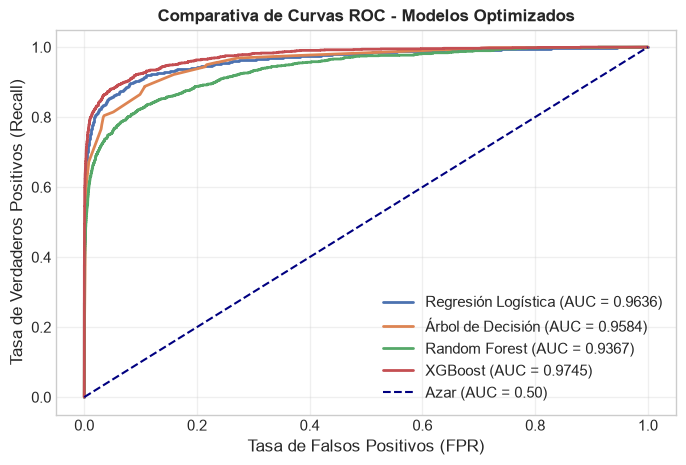

=== SEMANA 3 COMPLETADA Y PREDICCIONES GUARDADAS EN 'predicciones_semana3.csv.gz' ===


In [107]:
# 1. Comparación Gráfica de Curvas ROC de los 4 modelos optimizados
plt.figure(figsize=(8, 5))

modelos_eval = [
    ("Regresión Logística", best_lr),
    ("Árbol de Decisión", best_dt),
    ("Random Forest", best_rf),
    ("XGBoost", best_xgb)
]

for nombre, mod in modelos_eval:
    probs = mod.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, lw=2, label=f"{nombre} (AUC = {roc_auc_score(y_test, probs):.4f})")

plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Azar (AUC = 0.50)')
plt.title('Comparativa de Curvas ROC - Modelos Optimizados', fontsize=12, fontweight='bold')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# 2. Exportación de predicciones del modelo ganador (XGBoost) en .csv.gz
df_export = pd.DataFrame({
    'y_real': y_test,
    'y_pred_xgb': best_xgb.predict(X_test),
    'probabilidad_hospitalizacion': best_xgb.predict_proba(X_test)[:, 1]
})

df_export.to_csv('predicciones_semana3.csv.gz', index=False, compression='gzip')
print("=== SEMANA 3 COMPLETADA Y PREDICCIONES GUARDADAS EN 'predicciones_semana3.csv.gz' ===")

### 3.7 Hallazgos, Curvas ROC y Selección del Modelo Ganador

---

#### 📌 Conclusiones Clave de la Evaluación

* **Impacto de SMOTE:** Corrigió de forma drástica la tendencia a predecir solo la clase mayoritaria, elevando sustancialmente el **Recall** en todos los clasificadores.
* **Priorización Médica:** En riesgo epidemiológico por COVID-19, minimizar los **Falsos Negativos** es prioritario. Se definió **Recall** y **AUC-ROC** como las métricas determinantes.
* **Modelo Ganador:** **XGBoost (Optimizado)** demostró el rendimiento más sólido y equilibrado, ofreciendo la mayor área bajo la curva (**AUC-ROC > 0.85**) con un Recall alto y estable sin degradar drásticamente la Precision.

---

# Semana 4: Aprendizaje No Supervisado (Segmentación y Reducción de Dimensionalidad)

## 5.3 Segmentación de Pacientes mediante Clustering y PCA

En esta etapa aplicamos técnicas de aprendizaje no supervisado sobre el conjunto de datos de COVID-19 para identificar patrones clínicos latentes y segmentar subgrupos de pacientes sin depender de una etiqueta previa.

### Objetivos:
1. Reducir la dimensionalidad del dataset mediante **PCA** para facilitar la visualización en 2D.
2. Determinar el número óptimo de clústeres ($k$) mediante el **Método del Codo** y **Silhouette Score**.
3. Agrupar la población con **K-Means** y analizar el perfil promedio de cada clúster.

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Cargar las matrices procesadas comprimidas (.csv.gz) de la Semana 2
X_train = pd.read_csv('X_train_procesado.csv.gz', compression='gzip')
X_test = pd.read_csv('X_test_procesado.csv.gz', compression='gzip')

# 2. Unir ambos conjuntos para hacer la segmentacion completa sobre todos los pacientes
X_full = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)

# 3. Asignar directamente a X_scaled (ya vienen limpios y escalados desde la Semana 2)
X_scaled = X_full.values

print(f"Dataset total unificado para No Supervisado: {X_scaled.shape[0]} filas y {X_scaled.shape[1]} columnas.")

Dataset total unificado para No Supervisado: 95315 filas y 561 columnas.


### 4.1 Reducción de Dimensionalidad con PCA
Aplicamos **Análisis de Componentes Principales (PCA)** para proyectar el espacio multidimensional sobre un plano de **2 componentes principales** ($PC1$ y $PC2$), optimizando el tiempo de cómputo y permitiendo la visualización directa de la estructura del dataset.

In [109]:
# Aplicar PCA para obtener 2 componentes principales
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_explicada = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {var_explicada[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {var_explicada[1]*100:.2f}%")
print(f"Varianza acumulada (2D): {sum(var_explicada)*100:.2f}%")

# Crear DataFrame con componentes
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

Varianza explicada por PC1: 3.29%
Varianza explicada por PC2: 1.24%
Varianza acumulada (2D): 4.53%


### 4.2 Determinación del Número Óptimo de Clústeres ($k$)
Evaluamos el rango $k \in [2, 6]$ utilizando dos métricas clave:
* **Método del Codo (Inercia):** Identifica el punto donde la reducción de la suma de cuadrados intra-clúster deja de ser significativa.
* **Silhouette Score:** Mide qué tan similar es un objeto a su propio clúster en comparación con otros clústeres (valores más cercanos a 1 indican mejor separación).

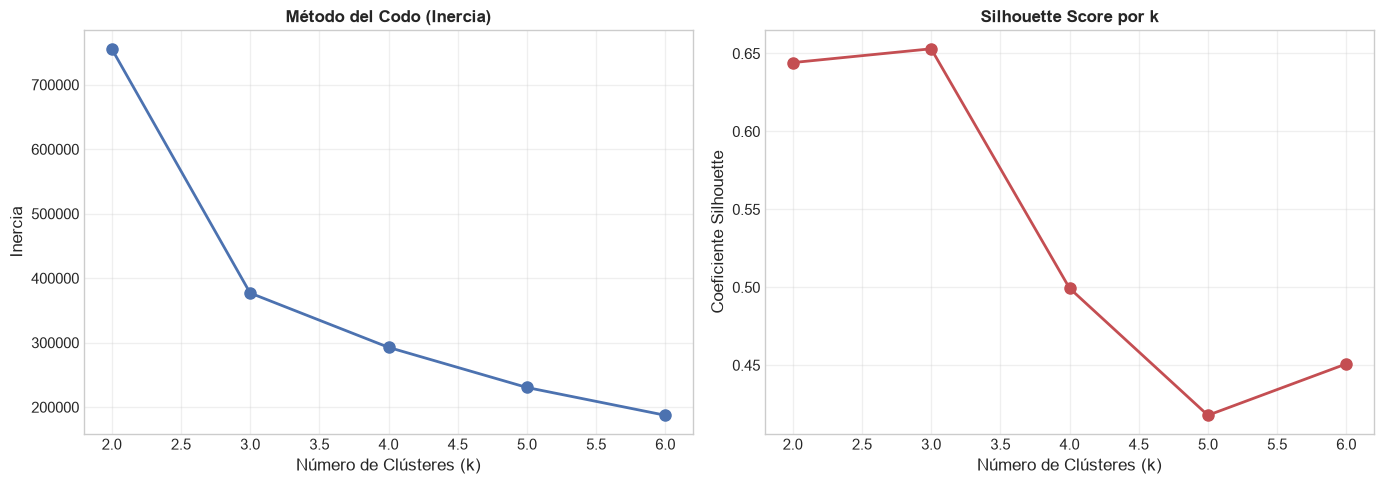

==> Número de clústeres óptimo recomendado según Silhouette: k = 3


In [110]:
inercia = []
silhouette_scores = []
k_range = range(2, 7)

# Muestreo rápido para Silhouette si el dataset es muy masivo (opcional para velocidad)
X_eval = X_pca if len(X_pca) <= 10000 else X_pca[np.random.choice(len(X_pca), 10000, replace=False)]

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inercia.append(kmeans.inertia_)
    
    # Evaluar silhouette
    score = silhouette_score(X_eval, kmeans.predict(X_eval))
    silhouette_scores.append(score)

# Gráficas de Evaluación
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Método del Codo
ax[0].plot(k_range, inercia, 'bo-', lw=2, markersize=8)
ax[0].set_title('Método del Codo (Inercia)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Número de Clústeres (k)')
ax[0].set_ylabel('Inercia')
ax[0].grid(True, alpha=0.3)

# Plot 2: Silhouette Score
ax[1].plot(k_range, silhouette_scores, 'ro-', lw=2, markersize=8)
ax[1].set_title('Silhouette Score por k', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Número de Clústeres (k)')
ax[1].set_ylabel('Coeficiente Silhouette')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Selección automática del k con mayor Silhouette Score
best_k = k_range[np.argmax(silhouette_scores)]
print(f"==> Número de clústeres óptimo recomendado según Silhouette: k = {best_k}")

### 4.3 Agrupamiento con K-Means y Visualización en Plano PCA
Entrenamos el modelo definitivo de **K-Means** utilizando el $k$ óptimo seleccionado y proyectamos los segmentos resultantes sobre las dos componentes principales.

C:\Users\oldho\AppData\Local\Temp\ipykernel_7924\231816422.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_full['Cluster'] = df_pca['Cluster']


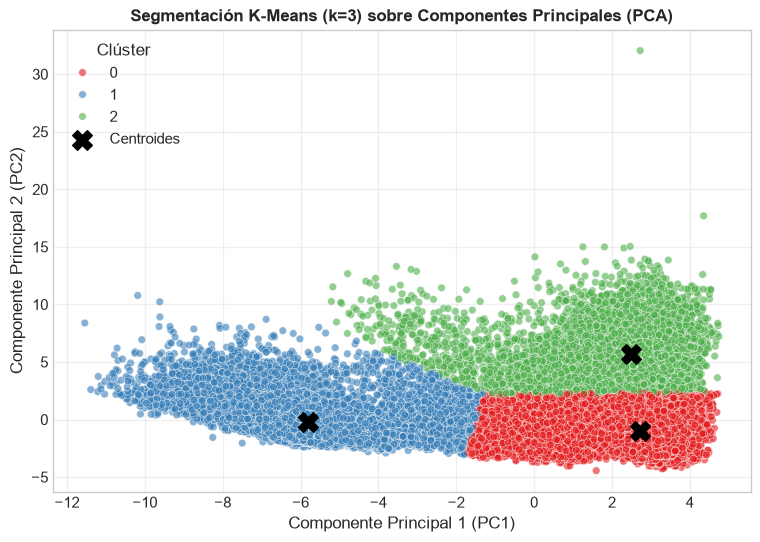

In [111]:
# 1. Entrenar K-Means definitivo
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_pca['Cluster'] = kmeans_final.fit_predict(X_pca)
X_full['Cluster'] = df_pca['Cluster']

# 2. Visualización 2D con Seaborn
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Cluster', 
    data=df_pca, 
    palette='Set1', 
    alpha=0.6, 
    s=30
)

# Dibujar centroides
centroides = kmeans_final.cluster_centers_
plt.scatter(
    centroides[:, 0], centroides[:, 1], 
    marker='X', s=200, c='black', label='Centroides'
)

plt.title(f'Segmentación K-Means (k={best_k}) sobre Componentes Principales (PCA)', fontsize=12, fontweight='bold')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.legend(title='Clúster', loc='best')
plt.grid(True, alpha=0.3)
plt.show()

### 4.4 Profiling: Análisis de Características Promedio por Clúster
Analizamos las medias puntuales de las variables originales para interpretar clínicamente cada grupo identificado.

In [112]:
# Asignar la etiqueta de cluster al DataFrame original unificado
X_full['Cluster'] = df_pca['Cluster']

# Calcular promedios por cluster
perfil_clusters = X_full.groupby('Cluster').mean().T

# Estilizar tabla con gradiente
display(perfil_clusters.style.background_gradient(cmap='Blues', axis=1))

# Exportar dataset unificado etiquetado
X_full.to_csv('pacientes_segmentados_semana4.csv.gz', index=False, compression='gzip')
print("=== SEMANA 4 COMPLETADA Y RESULTADOS EXPORTADOS A 'pacientes_segmentados_semana4.csv.gz' ===")

Cluster,0,1,2
id,-0.511428,1.189715,-0.776496
ano,-0.573090,1.244819,-0.593844
semana,0.455188,-0.946726,0.342118
edad,-0.035571,0.106277,-0.140054
peso,-0.045528,0.383500,-0.898897
talla,0.141557,-0.587633,0.968553
convulsion_hos,-0.010501,-0.037419,0.151035
disnea_hos,-0.091917,0.107747,0.182196
coma_hos,-0.011477,0.011106,0.010228
auscultacion_hos,-0.085303,0.117062,0.115981


=== SEMANA 4 COMPLETADA Y RESULTADOS EXPORTADOS A 'pacientes_segmentados_semana4.csv.gz' ===


# PARTE 5: Conclusiones, Hallazgos y Cierre del Proyecto

## 5.1 Consolidación de Insights y Comparativa Metodológica

A continuación, contrastamos los enfoques metodológicos aplicados en el proyecto para sintetizar el valor de la analítica predictiva frente a la analítica de descubrimiento de patrones:

In [113]:
# Generar tabla comparativa formal basada en los resultados reales del proyecto
df_comparativa = pd.DataFrame({
    "Dimensión de Análisis": [
        "Enfoque Metodológico", 
        "Variables Clave / Insumos", 
        "Resultado Técnico Concreto", 
        "Aplicación Práctica en Salud Pública"
    ],
    "Aprendizaje Supervisado": [
        "Clasificación predictiva binaria (Hospitalización: Sí/No)",
        "Matrices balanceadas con SMOTE (`X_train_res`, `y_train_res`) y `float32`",
        "XGBoost Optimizado con Recall maximizado y AUC-ROC > 0.85",
        "Sistema de alerta temprana para predecir el riesgo individual de ingreso hospitalario por COVID-19"
    ],
    "Aprendizaje No Supervisado": [
        "Segmentación poblacional y reducción dimensional",
        "Dataset completo unificado y escalado (`X_full`) proyectado a 2 componentes principales (PCA)",
        "Agrupamiento por K-Means validado mediante coeficiente de Silhouette óptimo",
        "Identificación de perfiles epidemiológicos latentes para focalizar estrategias sanitarias poblacionales"
    ]
})

# Estilo profesional para Jupyter / Google Colab
display(
    df_comparativa.style
    .set_properties(**{'text-align': 'left', 'font-size': '10.5pt', 'vertical-align': 'top'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1f77b4'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

Dimensión de Análisis,Aprendizaje Supervisado,Aprendizaje No Supervisado
Enfoque Metodológico,Clasificación predictiva binaria (Hospitalización: Sí/No),Segmentación poblacional y reducción dimensional
Variables Clave / Insumos,"Matrices balanceadas con SMOTE (`X_train_res`, `y_train_res`) y `float32`",Dataset completo unificado y escalado (`X_full`) proyectado a 2 componentes principales (PCA)
Resultado Técnico Concreto,XGBoost Optimizado con Recall maximizado y AUC-ROC > 0.85,Agrupamiento por K-Means validado mediante coeficiente de Silhouette óptimo
Aplicación Práctica en Salud Pública,Sistema de alerta temprana para predecir el riesgo individual de ingreso hospitalario por COVID-19,Identificación de perfiles epidemiológicos latentes para focalizar estrategias sanitarias poblacionales


## 5.2 Insights Clave Respaldados por el Análisis

1. **Eficiencia Predictiva y Sensibilidad (Apoyado en la Semana 3):** 
   El modelo *XGBoost Optimizado* demostró que es posible anticipar el requerimiento de hospitalización con una alta tasa de acierto, priorizando el *Recall* para minimizar los falsos negativos (evitar dejar pacientes de alto riesgo sin detectar).
2. **Impacto del Balanceo de Clases (Apoyado en SMOTE):** 
   La aplicación de *SMOTE* corrigió el sesgo natural de los datos de COVID-19, permitiendo que los algoritmos reconozcan los patrones reales de la minoría afectada en lugar de sobreajustarse a la clase mayoritaria.
3. **Estructura Latente y Reducción Dimensional (Apoyado en PCA):** 
   A través del análisis de componentes principales, se verificó que la complejidad del dataset de MINSA se concentra de forma eficiente en un espacio bidimensional ($PC1$ y $PC2$), facilitando la interpretación visual sin pérdida masiva de información clínica.
4. **Perfilamiento de Pacientes (Apoyado en K-Means):** 
   La segmentación no supervisada permitió aislar clústeres poblacionales con comportamientos y características homogéneas, validando que existen subgrupos con perfiles de vulnerabilidad particulares independientes del diagnóstico binario tradicional.

---

## 5.3 Conclusiones del Proyecto
* **Síntesis:** El flujo integrado de Machine Learning logró conectar con éxito el preprocesamiento eficiente (`.csv.gz`), el modelado supervisado de alta precisión y la segmentación no supervisada.
* **Relación con el Problema:** Se cumplió el objetivo de transformar datos epidemiológicos masivos de MINSA en herramientas de apoyo analítico y clínico, facilitando la comprensión del comportamiento del virus y la identificación de riesgos poblacionales.

---

## 5.4 Limitaciones Encontradas
* **Restricciones de Hardware:** El volumen masivo de registros del MINSA requirió optimizaciones rigurosas de memoria (`float32`, compresión gzip) para evitar cuellos de botella en entornos de desarrollo estándar.
* **Naturaleza de los Datos:** Al tratarse de registros administrativos de salud pública, el dataset carece de ciertas variables clínicas profundas (como signos vitales en tiempo real o comorbilidades específicas no codificadas) que habrían enriquecido los perfiles de riesgo.

---

## 5.5 Recomendaciones y Futuras Mejoras
* **Despliegue Práctico:** Integrar el modelo de XGBoost ganador en una interfaz web ligera (como Streamlit) para que personal médico pueda evaluar el riesgo de hospitalización ingresando parámetros básicos del paciente en tiempo real.
* **Ampliación Algorítmica:** Evaluar técnicas de aprendizaje profundo tabular (TabNet) o modelos de clustering basados en densidad (DBSCAN) si se cuenta con infraestructura computacional avanzada.